permutation testing to create a null distribution - birth year coef when birth year is scrambled, to compare to the observed metric (the coef I found when the data is correctly labeled) 

In [4]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from tqdm import tqdm 

In [5]:
combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/combined_gm_volumes.pkl')
# keep only classification_label=1 and snbb
combined_df = combined_df[(combined_df['classification_label'] == 1) | (combined_df['source'] == 'snbb')]

min_age = 30
max_age = 35

roi = 421

# volumes df
df = combined_df[(combined_df['age_in_years'] >= min_age) & (combined_df['age_in_years'] < max_age) & (combined_df['region_label'] == roi)]
df['age_in_years'] = pd.to_numeric(df['age_in_years'], errors='coerce')

/tmp/ipykernel_70158/1146647579.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age_in_years'] = pd.to_numeric(df['age_in_years'], errors='coerce')


In [6]:
# 1. Define your model formula
# Including TIV and Sex as standard neuroimaging covariates
formula = 'volume_mm3 ~ birth_year + C(sex) + tiv + age_in_years'

# 2. Get the observed coefficient for birth_year
model = smf.ols(formula, data=df).fit()
obs_beta = model.params['birth_year']

# 3. Permutation Loop
n_permutations = 10000
perm_betas = np.zeros(n_permutations)

# Create a copy to avoid modifying original data
perm_df = df.copy()

for i in tqdm(range(n_permutations)):
    # Shuffle only the birth_year column
    perm_df['birth_year'] = np.random.permutation(df['birth_year'].values)
    
    # Re-fit the model
    perm_model = smf.ols(formula, data=perm_df).fit()
    perm_betas[i] = perm_model.params['birth_year']

# 4. Calculate P-value
# The proportion of shuffled betas that are more extreme than our observed beta
p_value = np.mean(np.abs(perm_betas) >= np.abs(obs_beta))

print(f"Observed Beta: {obs_beta:.4f}")
print(f"Permutation P-value: {p_value:.4f}")

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:48<00:00, 206.39it/s]

Observed Beta: 4.8701
Permutation P-value: 0.0000


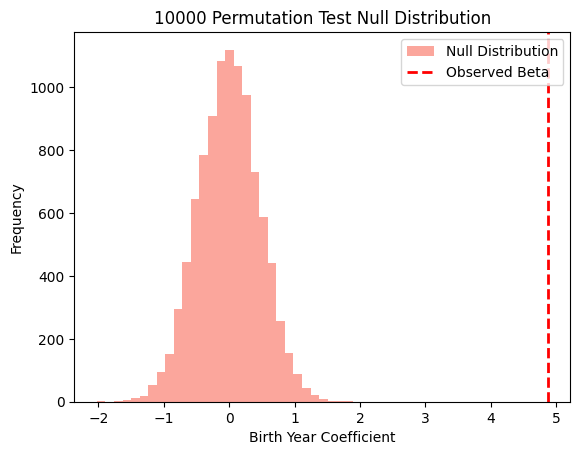

In [9]:
# plot the null and observed distribution
import matplotlib.pyplot as plt
plt.hist(perm_betas, bins=30, alpha=0.7, label='Null Distribution', color='salmon')
plt.axvline(obs_beta, color='red', linestyle='dashed', linewidth=2, label='Observed Beta')
plt.xlabel('Birth Year Coefficient')
plt.ylabel('Frequency')
plt.title(f"{n_permutations} Permutation Test Null Distribution")
plt.legend()
plt.show()